# Fish Length Estimation – Inference Notebook

This notebook performs inference using a two-stage deep learning pipeline:
1. A segmentation model to predict fish masks from input images
2. A regression model to estimate fish length based on predicted masks and auxiliary features

The notebook collects image-level predictions and aggregates them into fish-level statistics
for further analysis and visualization.


# 1. Pre-processing images

- image_folder
    - Day1
        - image1
        - image2
    - Day2
        - image1
        - image2
    - ...

## 1.1 Use SAM to automatically segment fishes region from the background

In [2]:
import os
import random
import cv2
import numpy as np
from tqdm.notebook import tqdm
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import os

data_root = "./Dataset/AC I/test/Images"  # Path for the source images
output_root = "./Dataset/AC I/test/Masks (SAM)"  # Path for the SAM's result

sam_checkpoint = "./Checkpoint/SAM/sam_vit_l_0b3195.pth"  # SAM checkpoint
model_type = "vit_l"  # SAM model type

os.environ["CUDA_VISIBLE_DEVICES"] = "5"
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading SAM model...")
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint).to(device)
mask_generator = SamAutomaticMaskGenerator(sam)
print("Model loaded successfully.")


def get_random_subset(file_list, min_ratio=0.1, max_ratio=0.2):
    count = len(file_list)
    if count == 0:
        return []
    num_to_select = random.randint(max(1, int(count * min_ratio)), max(1, int(count * max_ratio)))
    return random.sample(file_list, num_to_select)


def process_image(image_path, output_folder):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: failed to read {image_path}")
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    masks = mask_generator.generate(image_rgb)

    os.makedirs(output_folder, exist_ok=True)
    for idx, m in enumerate(masks):
        mask = (m['segmentation'].astype(np.uint8) * 255)
        save_path = os.path.join(output_folder, f"mask_{idx:03d}.png")
        cv2.imwrite(save_path, mask)


for root, dirs, files in os.walk(data_root):
    image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not image_files:
        continue

    selected_images = get_random_subset(image_files)
    print(f"Processing {len(selected_images)} images in {root}...")

    for image_name in tqdm(selected_images, desc=f"Processing {root}"):
        image_path = os.path.join(root, image_name)

        rel_path = os.path.relpath(root, data_root)
        image_stem = os.path.splitext(image_name)[0]
        output_folder = os.path.join(output_root, rel_path, image_stem)

        process_image(image_path, output_folder)

print("All done.")

Loading SAM model...
Model loaded successfully.
Processing 1 images in ./Dataset/AC I/test/Images/Day77/42...


Processing ./Dataset/AC I/test/Images/Day77/42: 100%|██████████| 1/1 [00:02<00:00,  2.76s/it]


Processing 1 images in ./Dataset/AC I/test/Images/Day77/63...


Processing ./Dataset/AC I/test/Images/Day77/63: 100%|██████████| 1/1 [00:02<00:00,  2.57s/it]


Processing 2 images in ./Dataset/AC I/test/Images/Day77/59...


...

Processing 1 images in ./Dataset/AC I/test/Images/Day126/15...


Processing ./Dataset/AC I/test/Images/Day126/15: 100%|██████████| 1/1 [00:02<00:00,  2.85s/it]


Processing 1 images in ./Dataset/AC I/test/Images/Day126/38...


Processing ./Dataset/AC I/test/Images/Day126/38: 100%|██████████| 1/1 [00:02<00:00,  2.79s/it]

All done.


## 1.2 Manually select the result image (binary mask) from the result folder and place the result image in the same folder structure

- image_folder
    - Day1
        - image1
        - image2
    - Day2
        - image1
        - image2
    - ...

## 1.3 Padding both original images and ground truth masks

In [3]:
import os
import cv2
import numpy as np
from tqdm.notebook import tqdm

image_path = ["./Dataset/AC I/test/Images", "./Dataset/AC I/test/images_padded_output"]
# mask_path = ["./masks_output", "./masks_padded_output"]
mask_path = None

roots = [image_path, mask_path]

for root in roots:
    if root is None:
        continue

    source_root, target_root = root

    # Ensure that the target directory exists
    os.makedirs(target_root, exist_ok=True)

    # Traverse the source directory
    for root, dirs, files in os.walk(source_root):
        # Filter image files
        image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if not image_files:
            continue

        # Compute the relative path with respect to the source root
        rel_path = os.path.relpath(root, source_root)
        target_dir = os.path.join(target_root, rel_path)
        os.makedirs(target_dir, exist_ok=True)

        # Process each image
        for image_file in tqdm(image_files, desc=f"Processing {rel_path}"):
            source_image_path = os.path.join(root, image_file)
            target_image_path = os.path.join(target_dir, image_file)

            # Read the image
            image = cv2.imread(source_image_path)
            if image is None:
                print(f"Warning: failed to read {source_image_path}")
                continue

            # Check image size
            h, w, c = image.shape
            if h == 1088 and w == 1920:
                # Already in the target size, save directly
                cv2.imwrite(target_image_path, image)
                continue

            # Create a new canvas and copy the original image to the top-left corner
            padded_image = np.zeros((1088, 1920, c), dtype=image.dtype)
            padded_image[:h, :w, :] = image

            # Save the padded image
            cv2.imwrite(target_image_path, padded_image)

    print("All images have been processed and saved to", target_root)

Processing Day126/38: 100%|██████████| 6/6 [00:00<00:00,  7.83it/s]

All images have been processed and saved to ./Dataset/AC I/test/images_padded_output


# 2. Testing the model

Inference:   0%|          | 0/150 [00:00<?, ?it/s]

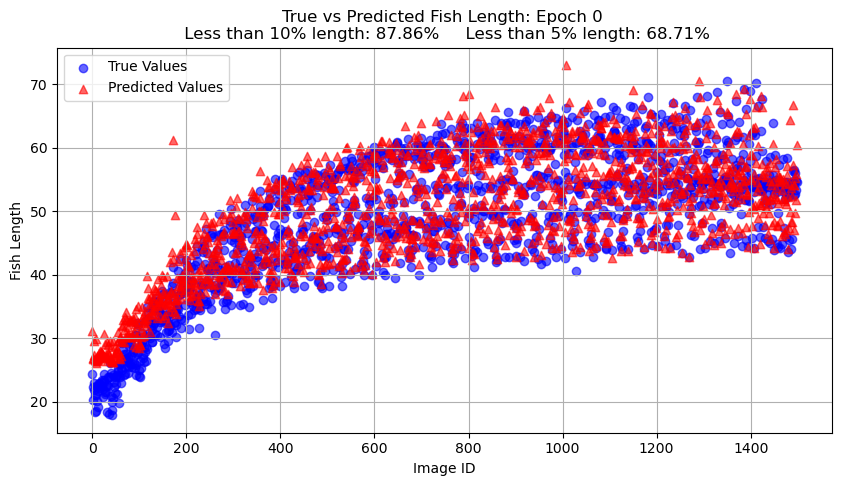

In [2]:
import os
import numpy as np
import torch
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
from FLN import FishLengthNet
from tools import create_dataloaders
import pandas as pd
from collections import defaultdict
from tools import draw_result

os.environ["CUDA_VISIBLE_DEVICES"] = "5"

image_path = "./Dataset/AC I/full/images_padded_output"
mask_path = ""
csv_path = "./Dataset/AC I/full/aging_cohort_I.csv"
save_path = "./Dataset/AC I/full/result.csv"
batch_size = 10

device = torch.device("cuda:0")
title_name = "Grid + Black Background"

weights_pths = [
    "./Checkpoint/FLN/Without_extra_features/mask_pred.pth",
    "./Checkpoint/FLN/Without_extra_features/len_pred.pth"
]


def infer_loop(models, dataloader):
    for name, model in models.items():
        model.eval()

    fish_info_list = []
    len_pred_values = []
    len_true_values = []

    with torch.no_grad():
        for images, masks, lengths, features, fish_infos in tqdm(dataloader, desc="Inference"):
            model = models["mask_pred"]
            images = images.to(device)

            mask_pred_outputs = model(images)

            model = models["len_pred"]
            features = features.to(device)
            lengths = lengths.to(device)

            len_pred_outputs = model(mask_pred_outputs, features)

            # save_mask(names, images, mask_pred_outputs, len_pred_outputs, values)

            fish_infos["len_pred_values"] = len_pred_outputs.cpu().squeeze().tolist()
            fish_infos["len_true_values"] = lengths.cpu().squeeze().tolist()
            fish_info_list.append(fish_infos)

            len_pred_values.extend(len_pred_outputs.cpu().numpy())
            len_true_values.extend(lengths.cpu().numpy())

        merged = defaultdict(list)
        for d in fish_info_list:
            for k, v in d.items():
                merged[k].extend(v)
        fish_info_dict = dict(merged)

        save_len_pred(fish_info_dict, save_path)
        # draw_test_result(fish_info_dict)

        len_pred_values = np.array(len_pred_values)
        len_true_values = np.array(len_true_values)
        current_len_pred_less_one_num = (np.abs(len_pred_values - len_true_values) / len_true_values < 0.1).sum()
        current_len_pred_less_half_num = (np.abs(len_pred_values - len_true_values) / len_true_values < 0.05).sum()

        draw_result(len_pred_values, len_true_values, current_len_pred_less_one_num, current_len_pred_less_half_num, 0,
                    False)


def save_mask(names, images, outputs, len_pred_values, len_true_values):
    sample_images = images.cpu().numpy()
    predicted_masks = outputs.cpu().numpy()
    len_pred_values = len_pred_values.cpu().numpy()
    len_true_values = len_true_values.cpu().numpy()

    folder_names = []
    for folder_name in os.listdir(image_path):
        file_names = [file_name.split(".png")[0] for file_name in os.listdir(os.path.join(image_path, folder_name))]
        for name in names:
            if name in file_names:
                folder_names.append(folder_name)

    base_output_dir = "./results/predicted_mask_test"

    for idx in range(len(sample_images)):
        input_img = sample_images[idx].transpose(1, 2, 0)
        mask = predicted_masks[idx].squeeze()
        image_name = names[idx]
        folder_name = folder_names[idx]

        folder_dir = os.path.join(base_output_dir, folder_name)
        os.makedirs(folder_dir, exist_ok=True)
        plt.imsave(f"{folder_dir}/{image_name}_input.png", input_img)
        plt.imsave(f"{folder_dir}/{image_name}_mask.png", mask, cmap='gray')

        print(f"Saved: {names[idx]}_input.png and {names[idx]}_mask.png")

        pred_len = len_pred_values[idx][0]
        true_len = len_true_values[idx][0]
        if true_len == 0:
            continue
        relative_error = float(abs(pred_len - true_len) / true_len)

        if relative_error > 0.10:
            error_level = "above_10_percent"
        elif relative_error > 0.05:
            error_level = "between_5_and_10_percent"
        else:
            error_level = "below_5_percent"

        error_save_dir = os.path.join("./results/predicted_mask_error", error_level, folder_name)
        os.makedirs(error_save_dir, exist_ok=True)

        plt.imsave(f"{error_save_dir}/{image_name}_input.png", input_img)
        plt.imsave(f"{error_save_dir}/{image_name}_mask.png", mask, cmap='gray')

        print(f"Saved: {image_name} with error {relative_error:.2%} into {error_save_dir}")


def save_len_pred(fish_info_dict, save_path):
    result_data = {
        'day_index': [f for f in fish_info_dict["day_index"]],  # 正则提取天数
        'image_name': [f for f in fish_info_dict["fish_name"]],
        'gt_length': [f for f in fish_info_dict["len_true_values"]],
        'pred_length': [f for f in fish_info_dict["len_pred_values"]],
        'type': [f for f in fish_info_dict["label"]],
        'image_path': [f for f in fish_info_dict["image_path"]],
    }

    if "fish_id" in fish_info_dict:
        result_data["fish_id"] = fish_info_dict["fish_id"]

    df = pd.DataFrame(result_data)
    df.to_csv(save_path, index=False)


def draw_test_result(fish_info_dict):
    # Iterate over each unique day index while preserving the original order
    for dat_index in list(dict.fromkeys(fish_info_dict['day_index'])):
        df = pd.DataFrame(fish_info_dict)
        df = df[df["day_index"] == dat_index][['fish_id', 'label', 'len_pred_values', 'len_true_values']]

        # Predictions from the same model using all available images per fish
        all_images_pred_df = df[df["label"] == "model_pred"].copy()

        # Predictions from the same model using the best selected image per fish
        best_image_pred_df = df[df["label"] == "model_pred_select"].copy()

        # Ground-truth mean length per fish ID
        true_per_id = df.groupby("fish_id", sort=True)["len_true_values"].mean()

        # Mean prediction per fish ID across all images
        mean_pred_all_images = all_images_pred_df.groupby("fish_id", sort=True)["len_pred_values"].mean()

        # One prediction per fish ID from the best selected image
        pred_best_image_per_id = best_image_pred_df.drop_duplicates("fish_id").set_index("fish_id")["len_pred_values"]

        all_ids = set(df["fish_id"])

        def sort_key(fid):
            try:
                return (0, float(fid))
            except Exception:
                return (1, str(fid))

        unique_ids_sorted = sorted(all_ids, key=sort_key)
        x_map = {fid: i for i, fid in enumerate(unique_ids_sorted)}
        x_positions = [x_map[fid] for fid in unique_ids_sorted]

        plt.figure(figsize=(12, 6))

        # All image-level predictions (red triangles)
        if not all_images_pred_df.empty:
            plt.scatter(
                all_images_pred_df["fish_id"].map(x_map),
                all_images_pred_df["len_pred_values"],
                marker="^", s=40, color="red", alpha=0.6,
                label="Model Predictions (from all images)"
            )

        # Mean prediction across all images (yellow circles)
        y_pred_mean = mean_pred_all_images.reindex(unique_ids_sorted).values
        plt.scatter(
            x_positions, y_pred_mean,
            marker='o', s=70, color='yellow', edgecolors='k', linewidths=0.5,
            label='Model Prediction (mean)'
        )

        # Ground-truth values (manual measurements)
        y_true = true_per_id.reindex(unique_ids_sorted).values
        plt.scatter(
            x_positions, y_true,
            marker='o', s=70, color='blue', edgecolors='k', linewidths=0.5,
            label='Manual Measurement (from the best selected image)'
        )

        # Prediction from the best selected image (green circles)
        y_other = pred_best_image_per_id.reindex(unique_ids_sorted).values
        plt.scatter(
            x_positions, y_other,
            marker='o', s=70, color='green', edgecolors='k', linewidths=0.5,
            label='Model Prediction (from best selected image)'
        )

        num_images_per_fish = all_images_pred_df.groupby('fish_id').size()
        labels = [f"{fid}\n(n={num_images_per_fish.get(fid, 0)})" for fid in unique_ids_sorted]

        # Compute statistics to visualize image-level prediction variability
        # (IQR and min–max range) from the same model
        pred_stats_all_images = all_images_pred_df.groupby('fish_id')['len_pred_values'].agg(
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            minv='min',
            maxv='max'
        ).reindex(unique_ids_sorted)

        q1 = pred_stats_all_images['q1'].values
        q3 = pred_stats_all_images['q3'].values
        minv = pred_stats_all_images['minv'].values
        maxv = pred_stats_all_images['maxv'].values

        iqr_height = q3 - q1
        upper_err = maxv - q3
        lower_err = q3 - minv
        yerr = np.vstack([lower_err, upper_err])

        plt.bar(
            x_positions,
            iqr_height,
            bottom=q1,
            yerr=yerr,
            color='#ff9999',
            edgecolor='red',
            alpha=0.35,
            capsize=6,
            linewidth=1.0,
            zorder=1
        )

        plt.xticks(ticks=x_positions, labels=labels, rotation=0)
        plt.xlabel("Fish ID")
        plt.ylabel("Fish Length (mm)")
        plt.title(f"{title_name} - {dat_index}")
        # plt.grid(True, linestyle='--', alpha=0.3)
        plt.ylim(25, 100)
        # plt.ylim(25, 140)
        plt.legend(loc='lower right')
        plt.tight_layout()
        plt.show()


models = {
    "mask_pred": FishLengthNet(model_type="mask_pred", num_classes=1),
    "len_pred": FishLengthNet(model_type="len_pred_new")
}

for name, model in models.items():
    models[name] = model.to(device)

for model_type, weighs_pth in zip(models, weights_pths):
    models[model_type].load_state_dict(torch.load(weighs_pth, weights_only=True))

day_indexes = None

dataloader, *_ = create_dataloaders(image_path=image_path, mask_path=mask_path, csv_path=csv_path, seq_length=5,
                                    batch_size=batch_size, day_indexes=day_indexes, used="Test", only_image=True)

infer_loop(models, dataloader)